Processing folder: Amlou
Processing folder: Ourkimen
Processing folder: Tagala


c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.3978 - loss: 2.2016 - val_accuracy: 0.3847 - val_loss: 2.1411
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.6153 - loss: 0.7839 - val_accuracy: 0.3882 - val_loss: 2.3682
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7896 - loss: 0.4838 - val_accuracy: 0.8960 - val_loss: 0.3255
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.8983 - loss: 0.2784 - val_accuracy: 0.9411 - val_loss: 0.1798
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.9264 - loss: 0.2004 - val_accuracy: 0.9809 - val_loss: 0.0708
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.9460 - loss: 0.1475 - val_accuracy: 0.9844 - val_loss: 0.0719
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.9663 - loss: 0.1032 - val_accuracy: 0.9931 - val_loss: 0.0346
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9792 - loss: 0.0669 - 

Test Accuracy: 99.31%


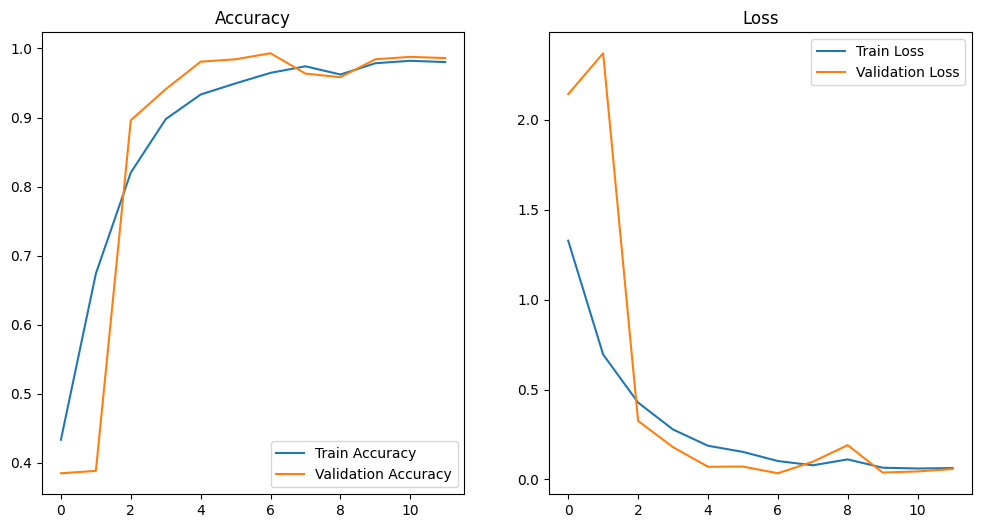

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


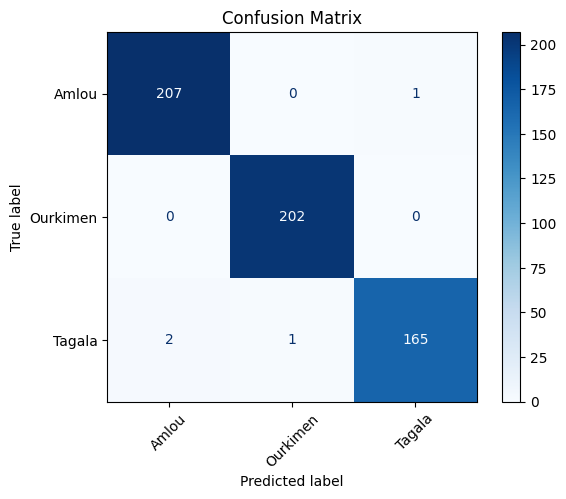

In [13]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def extract_features(file_path, n_mfcc=13, max_pad_len=100):
    try:
        audio, sample_rate = librosa.load(file_path, sr=16000)  
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc) 
        mfcc = librosa.util.normalize(mfcc) 
        pad_width = max(0, max_pad_len - mfcc.shape[1])  
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        mfcc = mfcc[:, :max_pad_len] 
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


paths = {
    'Amlou': r"C:\Users\dell\Data Science\Food Recognation\Tamazight_Project\Data_Tamazight\Amlou_wav",
    'Ourkimen': r"C:\Users\dell\Data Science\Food Recognation\Tamazight_Project\Data_Tamazight\Ourkimen_wav",
    'Tagala': r"C:\Users\dell\Data Science\Food Recognation\Tamazight_Project\Data_Tamazight\Tagla_wav"
}

data = []
labels = []

for label, folder in paths.items():
    print(f"Processing folder: {label}")
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        features = extract_features(file_path)
        if features is not None:
            data.append(features)
            labels.append(label)


data = np.array(data)
labels = np.array(labels)

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)  

data = data[..., np.newaxis]

X_train, X_temp, y_train, y_temp = train_test_split(data, categorical_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Data augmentation function
def augment_data(data):
    augmented_data = []
    for sample in data:
        # Add Gaussian noise
        noise = np.random.normal(0, 0.1, sample.shape)
        augmented_sample = sample + noise
        augmented_sample = np.clip(augmented_sample, -1, 1)  
        augmented_data.append(augmented_sample)
    return np.array(augmented_data)

augmented_data = augment_data(X_train)
X_train = np.concatenate([X_train, augmented_data])
y_train = np.concatenate([y_train, y_train])


model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(13, 100, 1), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), padding='same'),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


model.save("audio_classification_model_v3.h5")

joblib.dump(label_encoder, "label_encoder_v3.pkl")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) 
y_true_classes = np.argmax(y_test, axis=1)  

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = label_encoder.classes_  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()



In [14]:
# Map predictions to labels
def predict(test_files):
    predictions = []  # List to store predictions for all files
    for file in test_files:
        features = extract_features(file)
        if features is not None:
            features = features[np.newaxis, ..., np.newaxis]
            prediction = model.predict(features)
            predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
            print(f"File: {file} -> Predicted Label: {predicted_label[0]}")
            predictions.append(predicted_label[0])  # Append the prediction to the list
        else:
            print(f"Could not process file: {file}")
    return predictions  # Return the list of predictions

# Test files
test_files = [
    r"Test_Audio\Version1\test_A.wav",
    r"Test_Audio\Version1\test_O.wav",
    r"Test_Audio\Version1\test_T.wav"
]

# Predict words for all test files
predicted_words = predict(test_files)
print("Predicted Words:", predicted_words)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
File: Test_Audio\Version1\test_A.wav -> Predicted Label: Amlou
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
File: Test_Audio\Version1\test_O.wav -> Predicted Label: Ourkimen
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
File: Test_Audio\Version1\test_T.wav -> Predicted Label: Tagala
Predicted Words: ['Amlou', 'Ourkimen', 'Tagala']


In [15]:
# Map predictions to labels
def predict(test_files):
    predictions = []  # List to store predictions for all files
    for file in test_files:
        features = extract_features(file)
        if features is not None:
            features = features[np.newaxis, ..., np.newaxis]
            prediction = model.predict(features)
            predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
            print(f"File: {file} -> Predicted Label: {predicted_label[0]}")
            predictions.append(predicted_label[0])  # Append the prediction to the list
        else:
            print(f"Could not process file: {file}")
    return predictions  # Return the list of predictions

# Test files
test_files = [
    r"Test_Audio\Version2\amlou_V2.wav",
    r"Test_Audio\Version2\ourkimen_v2.wav",
    r"Test_Audio\Version2\tagla_v2.wav"
]

# Predict words for all test files
predicted_words = predict(test_files)
print("Predicted Words:", predicted_words)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
File: Test_Audio\Version2\amlou_V2.wav -> Predicted Label: Amlou
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
File: Test_Audio\Version2\ourkimen_v2.wav -> Predicted Label: Ourkimen
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
File: Test_Audio\Version2\tagla_v2.wav -> Predicted Label: Tagala
Predicted Words: ['Amlou', 'Ourkimen', 'Tagala']


In [16]:
# Map predictions to labels
def predict(test_files):
    predictions = []  # List to store predictions for all files
    for file in test_files:
        features = extract_features(file)
        if features is not None:
            features = features[np.newaxis, ..., np.newaxis]
            prediction = model.predict(features)
            predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
            print(f"File: {file} -> Predicted Label: {predicted_label[0]}")
            predictions.append(predicted_label[0])  # Append the prediction to the list
        else:
            print(f"Could not process file: {file}")
    return predictions  # Return the list of predictions

# Test files
test_files = [
    r"Test_Audio\Version3\amlou_v3.wav",
    r"Test_Audio\Version3\ourkimen_v3.wav",
    r"Test_Audio\Version3\tagala_V3.wav"
]

# Predict words for all test files
predicted_words = predict(test_files)
print("Predicted Words:", predicted_words)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
File: Test_Audio\Version3\amlou_v3.wav -> Predicted Label: Amlou
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
File: Test_Audio\Version3\ourkimen_v3.wav -> Predicted Label: Ourkimen
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
File: Test_Audio\Version3\tagala_V3.wav -> Predicted Label: Tagala
Predicted Words: ['Amlou', 'Ourkimen', 'Tagala']


In [17]:
# Map predictions to labels
def predict(test_files):
    predictions = []  # List to store predictions for all files
    for file in test_files:
        features = extract_features(file)
        if features is not None:
            features = features[np.newaxis, ..., np.newaxis]
            prediction = model.predict(features)
            predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])
            print(f"File: {file} -> Predicted Label: {predicted_label[0]}")
            predictions.append(predicted_label[0])  # Append the prediction to the list
        else:
            print(f"Could not process file: {file}")
    return predictions  # Return the list of predictions

# Test files
test_files = [
    r"Test_Audio\Version4\amlou_v4.wav",
    r"Test_Audio\Version4\ourkimen_v4.wav",
    r"Test_Audio\Version4\tagala_v4.wav"
]

# Predict words for all test files
predicted_words = predict(test_files)
print("Predicted Words:", predicted_words)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
File: Test_Audio\Version4\amlou_v4.wav -> Predicted Label: Tagala
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
File: Test_Audio\Version4\ourkimen_v4.wav -> Predicted Label: Ourkimen
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
File: Test_Audio\Version4\tagala_v4.wav -> Predicted Label: Tagala
Predicted Words: ['Tagala', 'Ourkimen', 'Tagala']
